# Medical Image Analysis Using a Convolutional Neural Network (CNN)

## Pneumonia Detection from Chest X-Ray Images — PyTorch

This project uses a Convolutional Neural Network (CNN) implemented with PyTorch to classify chest X-ray images into two categories: **NORMAL** and **PNEUMONIA**.


In [26]:
# Import required libraries

import os

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Set random seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"PyTorch version: {torch.__version__}")
print(f"Using device: {device}")

PyTorch version: 2.11.0+cu128
Using device: cuda


## 1. Dataset Loading and Preprocessing

The Chest X-Ray Images (Pneumonia) dataset is used for this project. The images are classified into two categories: **NORMAL** and **PNEUMONIA**.

The training data will be divided into training and validation sets, while the provided test set will remain separate for final model evaluation.

In [27]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
chest-xray-pneumonia.zip: Skipping, found more recently modified local copy (use --force to force download)


In [28]:
# Extract the downloaded dataset

import zipfile

zip_path = "/content/chest-xray-pneumonia.zip"
extract_path = "/content/chest_xray_data"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")


Dataset extracted successfully.


In [29]:
# Check extracted dataset folders

for root, dirs, files in os.walk("/content/chest_xray_data"):
    if "NORMAL" in dirs or "PNEUMONIA" in dirs:
        print(root)

/content/chest_xray_data/chest_xray/chest_xray/train
/content/chest_xray_data/chest_xray/chest_xray/test
/content/chest_xray_data/chest_xray/chest_xray/val
/content/chest_xray_data/chest_xray/train
/content/chest_xray_data/chest_xray/__MACOSX/chest_xray/train
/content/chest_xray_data/chest_xray/__MACOSX/chest_xray/test
/content/chest_xray_data/chest_xray/__MACOSX/chest_xray/val
/content/chest_xray_data/chest_xray/test
/content/chest_xray_data/chest_xray/val


In [30]:
# Define dataset paths

train_dir = "/content/chest_xray_data/chest_xray/train"
test_dir = "/content/chest_xray_data/chest_xray/test"

print("Training folder exists:", os.path.exists(train_dir))
print("Test folder exists:", os.path.exists(test_dir))

Training folder exists: True
Test folder exists: True


In [31]:
# Define image transformations

transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor()
])

print("Image transformations defined successfully.")

Image transformations defined successfully.


In [32]:
# Load training and test datasets

full_train_dataset = ImageFolder(
    root=train_dir,
    transform=transform
)

test_dataset = ImageFolder(
    root=test_dir,
    transform=transform
)

print("Classes:", full_train_dataset.classes)
print("Class mapping:", full_train_dataset.class_to_idx)

print("Total training images:", len(full_train_dataset))
print("Total test images:", len(test_dataset))

Classes: ['NORMAL', 'PNEUMONIA']
Class mapping: {'NORMAL': 0, 'PNEUMONIA': 1}
Total training images: 5216
Total test images: 624


In [47]:
# Load the original validation dataset

val_dir = "/content/chest_xray_data/chest_xray/val"

val_dataset_original = ImageFolder(
    root=val_dir,
    transform=transform
)

print("Original training images:", len(full_train_dataset))
print("Original validation images:", len(val_dataset_original))
print("Test images:", len(test_dataset))

Original training images: 5216
Original validation images: 16
Test images: 624


In [33]:
from torch.utils.data import ConcatDataset

# Combine the original training and validation sets
combined_dataset = ConcatDataset([
    full_train_dataset,
    val_dataset_original
])

print("Combined training pool:", len(combined_dataset))
print("Test images:", len(test_dataset))

Combined training pool: 5232
Test images: 624


In [34]:
# Split combined dataset into training and validation sets

train_size = int(0.8 * len(combined_dataset))
val_size = len(combined_dataset) - train_size

train_dataset, val_dataset = random_split(
    combined_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))

Training images: 4185
Validation images: 1047
Test images: 624


## 2. Exploratory Data Analysis

Exploratory data analysis is performed to examine the distribution of the NORMAL and PNEUMONIA classes and to visualize sample chest X-ray images from the dataset.

NORMAL: 1349 images
PNEUMONIA: 3883 images


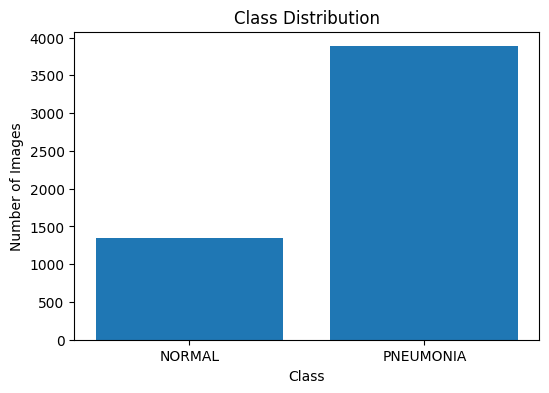

In [48]:
# Check class distribution

train_counts = np.bincount(full_train_dataset.targets)
val_counts = np.bincount(val_dataset_original.targets)

class_counts = train_counts + val_counts

for class_name, count in zip(full_train_dataset.classes, class_counts):
    print(f"{class_name}: {count} images")

# Plot class distribution
plt.figure(figsize=(6, 4))
plt.bar(full_train_dataset.classes, class_counts)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

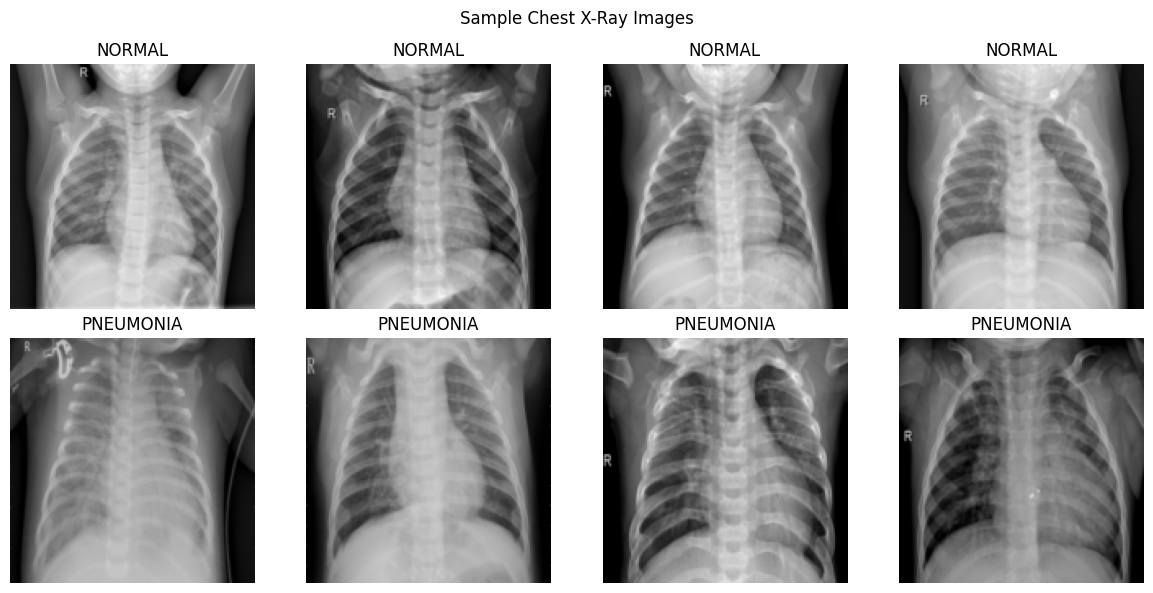

In [49]:
# Display sample images from each class

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for class_idx, class_name in enumerate(full_train_dataset.classes):

    indices = [
        i for i, label in enumerate(full_train_dataset.targets)
        if label == class_idx
    ][:4]

    for j, idx in enumerate(indices):
        image, label = full_train_dataset[idx]

        image = image.permute(1, 2, 0)

        axes[class_idx, j].imshow(image, cmap="gray")
        axes[class_idx, j].set_title(class_name)
        axes[class_idx, j].axis("off")

plt.suptitle("Sample Chest X-Ray Images")
plt.tight_layout()
plt.show()

### EDA Findings

The combined training pool contains **5,232 chest X-ray images**, consisting of **1,349 NORMAL images** and **3,883 PNEUMONIA images**. This shows that the dataset is imbalanced, with considerably more PNEUMONIA images than NORMAL images.

The sample images show examples of chest X-rays from both classes. Before being passed to the CNN, all images are resized to **150 × 150 pixels** and converted into PyTorch tensors.

In [35]:
# Create DataLoaders

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Training batches: 131
Validation batches: 33
Test batches: 20


## 3. CNN Model Implementation

A custom Convolutional Neural Network (CNN) is implemented using PyTorch. The network consists of three convolutional blocks for feature extraction, followed by fully connected layers for classification.

Each convolutional block uses a convolutional layer, ReLU activation function, and max-pooling layer. The final fully connected layer produces two outputs corresponding to the **NORMAL** and **PNEUMONIA** classes.

In [36]:
class CustomCNN(nn.Module):
    def __init__(self):
        super(CustomCNN, self).__init__()

        # 1. Feature Extraction: 3 Convolutional Blocks
        self.conv_layers = nn.Sequential(
            # Block 1: (3, 150, 150) -> (32, 75, 75)
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2: (32, 75, 75) -> (64, 37, 37)
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 3: (64, 37, 37) -> (128, 18, 18)
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # 2. Classification: Fully Connected Layers
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=128 * 18 * 18, out_features=128),
            nn.ReLU(),
            nn.Linear(in_features=128, out_features=2)
        )

    def forward(self, x):
        features = self.conv_layers(x)
        logits = self.fc_layers(features)
        return logits


model = CustomCNN().to(device)

print(model)
print("\nUsing device:", device)

CustomCNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=41472, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
)

Using device: cuda


### CNN Architecture

The CNN contains three convolutional layers with **32, 64, and 128 filters**, respectively. Each convolution uses a **3 × 3 kernel** with padding of 1, followed by a ReLU activation function and a **2 × 2 max-pooling layer**.

After the three convolutional blocks, the resulting feature maps are flattened and passed through a fully connected layer containing **128 neurons**. The final layer contains **2 output neurons**, representing the NORMAL and PNEUMONIA classes.

The model receives RGB images resized to **150 × 150 pixels** as input.

In [37]:
# Define loss function and optimizer

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Learning rate:", optimizer.param_groups[0]['lr'])

Loss function: CrossEntropyLoss()
Learning rate: 0.001


## 4. Model Training

The CNN is trained for **10 epochs** using the **Adam optimizer** with a learning rate of **0.001** and **CrossEntropyLoss** as the loss function.

During each epoch, the model performs forward propagation, loss calculation, backpropagation, and weight updates on the training dataset. The model is then evaluated on the validation dataset. Training and validation loss and accuracy are recorded for each epoch to monitor model performance.

In [38]:
# Train the CNN

NUM_EPOCHS = 10

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(NUM_EPOCHS):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader.dataset)
    train_accuracy = correct / total

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = running_val_loss / len(val_loader.dataset)
    val_accuracy = val_correct / val_total

    # Store results
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
        f"Train Loss: {train_loss:.4f}, "
        f"Train Accuracy: {train_accuracy:.4f}, "
        f"Val Loss: {val_loss:.4f}, "
        f"Val Accuracy: {val_accuracy:.4f}"
    )

Epoch [1/10] Train Loss: 0.3762, Train Accuracy: 0.8397, Val Loss: 0.1363, Val Accuracy: 0.9513
Epoch [2/10] Train Loss: 0.1080, Train Accuracy: 0.9572, Val Loss: 0.1112, Val Accuracy: 0.9647
Epoch [3/10] Train Loss: 0.0956, Train Accuracy: 0.9646, Val Loss: 0.0880, Val Accuracy: 0.9704
Epoch [4/10] Train Loss: 0.0703, Train Accuracy: 0.9730, Val Loss: 0.1329, Val Accuracy: 0.9542
Epoch [5/10] Train Loss: 0.0687, Train Accuracy: 0.9754, Val Loss: 0.0807, Val Accuracy: 0.9713
Epoch [6/10] Train Loss: 0.0524, Train Accuracy: 0.9804, Val Loss: 0.0808, Val Accuracy: 0.9685
Epoch [7/10] Train Loss: 0.0406, Train Accuracy: 0.9845, Val Loss: 0.0677, Val Accuracy: 0.9761
Epoch [8/10] Train Loss: 0.0257, Train Accuracy: 0.9902, Val Loss: 0.0938, Val Accuracy: 0.9752
Epoch [9/10] Train Loss: 0.0247, Train Accuracy: 0.9921, Val Loss: 0.0687, Val Accuracy: 0.9761
Epoch [10/10] Train Loss: 0.0245, Train Accuracy: 0.9907, Val Loss: 0.1240, Val Accuracy: 0.9589


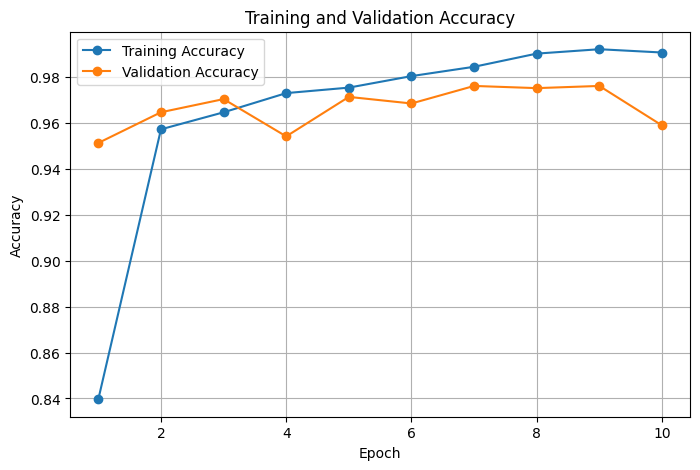

In [39]:
# Plot training and validation accuracy

epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs, train_accuracies, marker='o', label='Training Accuracy')
plt.plot(epochs, val_accuracies, marker='o', label='Validation Accuracy')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()


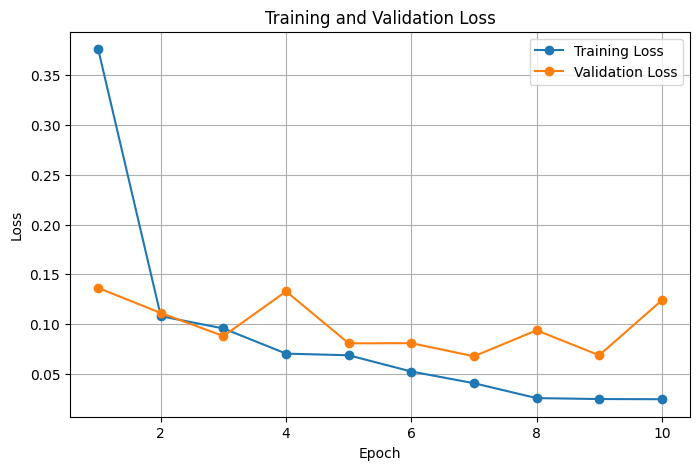

In [40]:
# Plot training and validation loss

plt.figure(figsize=(8, 5))

plt.plot(epochs, train_losses, marker='o', label='Training Loss')
plt.plot(epochs, val_losses, marker='o', label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

## 5. Model Evaluation

The trained CNN is evaluated using the independent test dataset, which was not used during model training or validation. Performance is assessed using test loss, accuracy, confusion matrix, precision, recall, F1-score, classification report, ROC curve, and AUC score.

In [41]:
# Evaluate the model on the test dataset

model.eval()

test_loss = 0.0
correct = 0
total = 0

all_labels = []
all_predictions = []
all_probabilities = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item() * images.size(0)

        # Convert logits to probabilities
        probabilities = torch.softmax(outputs, dim=1)

        # Predicted class
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

        # Probability of PNEUMONIA class (class 1)
        all_probabilities.extend(probabilities[:, 1].cpu().numpy())

test_loss = test_loss / len(test_loader.dataset)
test_accuracy = correct / total

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy (%): {test_accuracy * 100:.2f}%")

Test Loss: 3.1806
Test Accuracy: 0.6715
Test Accuracy (%): 67.15%


In [42]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=["NORMAL", "PNEUMONIA"]
    )
)

Classification Report:
              precision    recall  f1-score   support

      NORMAL       1.00      0.12      0.22       234
   PNEUMONIA       0.66      1.00      0.79       390

    accuracy                           0.67       624
   macro avg       0.83      0.56      0.51       624
weighted avg       0.78      0.67      0.58       624



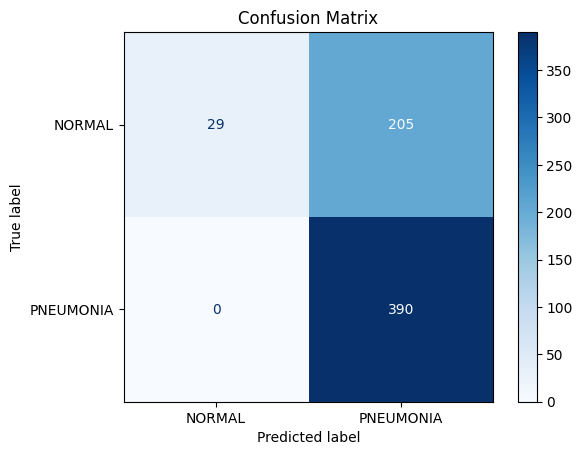

In [43]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["NORMAL", "PNEUMONIA"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

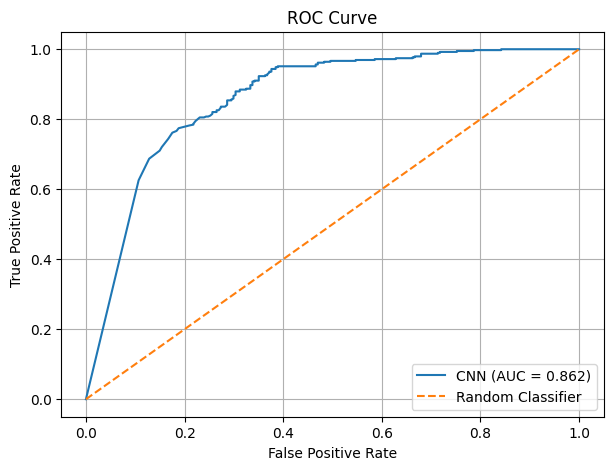

AUC Score: 0.8625


In [44]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(all_labels, all_probabilities)

# Calculate AUC
auc_score = roc_auc_score(all_labels, all_probabilities)

# Plot ROC curve
plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"CNN (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)

plt.show()

print(f"AUC Score: {auc_score:.4f}")

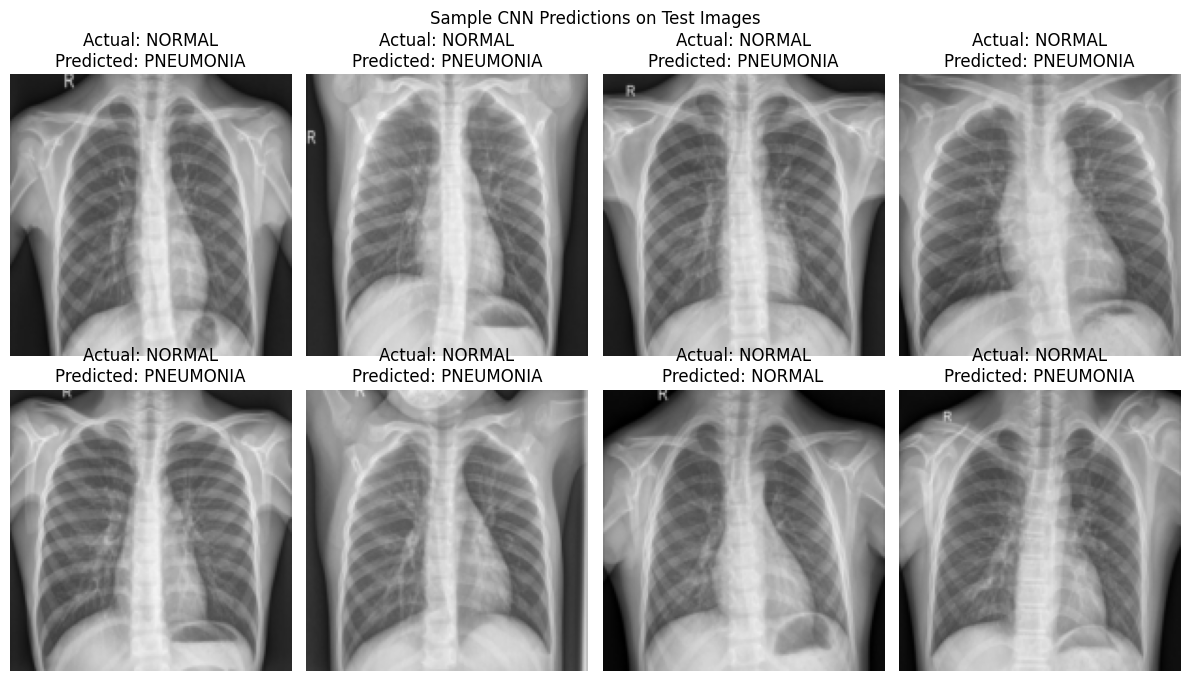

In [45]:
# Display sample model predictions

model.eval()

images, labels = next(iter(test_loader))

images_device = images.to(device)

with torch.no_grad():
    outputs = model(images_device)
    probabilities = torch.softmax(outputs, dim=1)
    _, predictions = torch.max(outputs, 1)

# Move predictions back to CPU
predictions = predictions.cpu()

class_names = ["NORMAL", "PNEUMONIA"]

# Display 8 sample predictions
fig, axes = plt.subplots(2, 4, figsize=(12, 7))

for i, ax in enumerate(axes.flat):
    image = images[i].permute(1, 2, 0)

    actual = class_names[labels[i].item()]
    predicted = class_names[predictions[i].item()]

    ax.imshow(image, cmap="gray")
    ax.set_title(
        f"Actual: {actual}\nPredicted: {predicted}"
    )
    ax.axis("off")

plt.suptitle("Sample CNN Predictions on Test Images")
plt.tight_layout()
plt.show()

## 6. Results and Discussion

The CNN achieved a test accuracy of **67.15%** with a test loss of **3.1806**.

The classification report showed a clear difference in performance between the two classes. For the **PNEUMONIA** class, the model achieved a recall of **1.00**, successfully identifying almost all pneumonia cases in the test dataset. For the **NORMAL** class, recall was considerably lower at **0.12**, indicating that many normal X-rays were incorrectly classified as pneumonia.

The model achieved a precision of **1.00** for NORMAL and **0.66** for PNEUMONIA, with F1-scores of **0.22** and **0.79**, respectively. These results show that the model has a strong tendency to predict the PNEUMONIA class.

The training dataset contains substantially more PNEUMONIA images than NORMAL images. This class imbalance may have contributed to the model's tendency to classify images as PNEUMONIA.

The model achieved an **AUC score of 0.8625**, indicating that it retains useful ability to distinguish between NORMAL and PNEUMONIA images across different classification thresholds.

Although the model achieved high training and validation performance, its substantially lower performance on the independent test set indicates limited generalization to unseen test images.

### 7. Conclusion

This project implemented a custom Convolutional Neural Network (CNN) using PyTorch to classify chest X-ray images as NORMAL or PNEUMONIA. The model was trained using an 80/20 training-validation split and evaluated on a separate test dataset of 624 images.

The model achieved **67.15% test accuracy** and an **AUC score of 0.8625**. It achieved very high recall for PNEUMONIA (**1.00**) but substantially lower recall for NORMAL (**0.12**). This indicates that the model was highly sensitive to pneumonia cases but frequently classified normal X-rays as pneumonia.

The results demonstrate the application of a CNN to medical image classification and highlight the importance of considering class-specific metrics such as precision, recall, and F1-score rather than relying only on overall accuracy.

In [46]:
# Save the trained model

torch.save(
    model.state_dict(),
    "/content/pneumonia_cnn_pytorch.pth"
)

print("Model saved successfully.")

Model saved successfully.
